In [5]:
data_sekolah <- read.csv("/content/JPM dan Jumlah Sekolah.csv")

In [6]:
str(data_sekolah)

'data.frame':	15 obs. of  3 variables:
 $ Wilayah                           : chr  "Lampung Barat" "Tanggamus" "Lampung Selatan" "Lampung Timur" ...
 $ Jumlah.Penduduk.Miskin..ribu.jiwa.: num  31.2 63.6 127.7 132.2 127.8 ...
 $ Jumlah.Sekolah                    : int  314 546 799 892 1136 623 487 376 422 388 ...


In [7]:
head(data_sekolah)

,Wilayah,Jumlah.Penduduk.Miskin..ribu.jiwa.,Jumlah.Sekolah
,<chr>,<dbl>,<int>
1,Lampung Barat,31.23,314
2,Tanggamus,63.56,546
3,Lampung Selatan,127.74,799
4,Lampung Timur,132.17,892
5,Lampung Tengah,127.83,1136
6,Lampung Utara,98.98,623


In [8]:
n_total <- nrow(data_sekolah)
sample_size <- floor(n_total * 0.5) # Misalnya ambil 50% data


In [9]:
set.seed(123)
sampled_indices <- sample(1:n_total, size = sample_size, replace = FALSE)
data_sampled <- data_sekolah[sampled_indices, ]

cat("Jumlah Observasi Asli:", n_total, "\n")
cat("Jumlah Observasi Sampel:", nrow(data_sampled), "\n")
print(data_sampled)

Jumlah Observasi Asli: 15 
Jumlah Observasi Sampel: 7 
           Wilayah Jumlah.Penduduk.Miskin..ribu.jiwa. Jumlah.Sekolah
15           Metro                              11.58            140
3  Lampung Selatan                             127.74            799
14  Bandar Lampung                              80.19            522
10       Pringsewu                              31.66            388
2        Tanggamus                              63.56            546
6    Lampung Utara                              98.98            623
5   Lampung Tengah                             127.83           1136


In [10]:
# Sampling acak dengan pengulangan
sample_size_with_replacement <- floor(n_total * 0.5)

set.seed(456)
sampled_indices_with_replacement <- sample(1:n_total,
                                           size = sample_size_with_replacement,
                                           replace = TRUE)
data_sampled_with_replacement <- data_sekolah[sampled_indices_with_replacement, ]

cat("Jumlah Observasi Asli:", n_total, "\n")
cat("Jumlah Observasi Sampel (dengan pengulangan):",
    nrow(data_sampled_with_replacement), "\n")
print(data_sampled_with_replacement)

Jumlah Observasi Asli: 15 
Jumlah Observasi Sampel (dengan pengulangan): 7 
                Wilayah Jumlah.Penduduk.Miskin..ribu.jiwa. Jumlah.Sekolah
13        Pesisir Barat                              19.50            183
5        Lampung Tengah                             127.83           1136
3       Lampung Selatan                             127.74            799
6         Lampung Utara                              98.98            623
5.1      Lampung Tengah                             127.83           1136
12  Tulang Bawang Barat                              19.04            277
11               Mesuji                              12.14            225


In [11]:
# Fungsi Jackknife Manual (Mean)
jackknife_analysis <- function(data) {
  n <- length(data)
  theta_full <- mean(data, na.rm = TRUE)
  theta_i <- numeric(n)

  for (i in 1:n) {
    subsample <- data[-i]
    theta_i[i] <- mean(subsample, na.rm = TRUE)
  }

  theta_dot <- mean(theta_i, na.rm = TRUE)
  bias_jack <- (n - 1) * (theta_dot - theta_full)
  var_jack <- ((n - 1) / n) * sum((theta_i - theta_dot)^2, na.rm = TRUE)
  se_jack <- sqrt(var_jack)

  return(list(
    mean_full = theta_full,
    bias_estimate = bias_jack,
    std_error = se_jack,
    jackknife_values = theta_i
  ))
}

hasil_jackknife_mean <- jackknife_analysis(
  data_sekolah$Jumlah.Penduduk.Miskin..ribu.jiwa.
)

cat("--- Hasil Analisis Jackknife Mean ---\n")
cat("Mean Sampel Penuh: ", hasil_jackknife_mean$mean_full, "\n")
cat("Estimasi Bias Jackknife (Mean): ", hasil_jackknife_mean$bias_estimate, "\n")
cat("Standard Error Jackknife (Mean): ", hasil_jackknife_mean$std_error, "\n")
cat("Nilai Jackknife (6 pertama): ", head(hasil_jackknife_mean$jackknife_values), "\n")

--- Hasil Analisis Jackknife Mean ---
Mean Sampel Penuh:  59.134 
Estimasi Bias Jackknife (Mean):  0 
Standard Error Jackknife (Mean):  11.29903 
Nilai Jackknife (6 pertama):  61.12714 58.81786 54.23357 53.91714 54.22714 56.28786 


In [12]:
# Fungsi Jackknife Manual (Median)
jackknife_median_analysis <- function(data) {
  n <- length(data)
  theta_full <- median(data, na.rm = TRUE)
  theta_jack_i <- numeric(n)

  for (i in 1:n) {
    subsample <- data[-i]
    theta_jack_i[i] <- median(subsample, na.rm = TRUE)
  }

  theta_dot <- mean(theta_jack_i, na.rm = TRUE)
  bias_jack <- (n - 1) * (theta_dot - theta_full)
  var_jack <- ((n - 1) / n) * sum((theta_jack_i - theta_dot)^2, na.rm = TRUE)
  se_jack <- sqrt(var_jack)

  return(list(
    median_full = theta_full,
    bias_estimate = bias_jack,
    std_error = se_jack,
    jackknife_values = theta_jack_i
  ))
}

hasil_jackknife_median <- jackknife_median_analysis(
  data_sekolah$Jumlah.Penduduk.Miskin..ribu.jiwa.
)

cat("--- Hasil Analisis Jackknife Median ---\n")
cat("Median Sampel Penuh: ", hasil_jackknife_median$median_full, "\n")
cat("Estimasi Bias Jackknife (Median): ", hasil_jackknife_median$bias_estimate, "\n")
cat("Standard Error Jackknife (Median): ", hasil_jackknife_median$std_error, "\n")
cat("Nilai Jackknife (6 pertama): ", head(hasil_jackknife_median$jackknife_values), "\n")

--- Hasil Analisis Jackknife Median ---
Median Sampel Penuh:  44.17 
Estimasi Bias Jackknife (Median):  -4.181333 
Standard Error Jackknife (Median):  13.52182 
Nilai Jackknife (6 pertama):  47.63 40.15 40.15 40.15 40.15 40.15 


In [13]:
# Korelasi Pearson
n <- nrow(data_sekolah)
var_x <- "Jumlah.Penduduk.Miskin..ribu.jiwa."
var_y <- "Jumlah.Sekolah"

theta_full <- cor(data_sekolah[[var_x]], data_sekolah[[var_y]], method = "pearson")

cat("--- Hasil Sampel Penuh ---\n")
cat("Jumlah Observasi (n):", n, "\n")
cat("Korelasi Pearson:", theta_full, "\n\n")

--- Hasil Sampel Penuh ---
Jumlah Observasi (n): 15 
Korelasi Pearson: 0.9480756 



In [14]:
mean_jpm <- mean(data_sekolah$Jumlah.Penduduk.Miskin..ribu.jiwa., na.rm = TRUE)
median_jpm <- median(data_sekolah$Jumlah.Penduduk.Miskin..ribu.jiwa., na.rm = TRUE)

cat("Mean Jumlah Penduduk Miskin: ", mean_jpm, "\n")
cat("Median Jumlah Penduduk Miskin: ", median_jpm, "\n")

Mean Jumlah Penduduk Miskin:  59.134 
Median Jumlah Penduduk Miskin:  44.17 


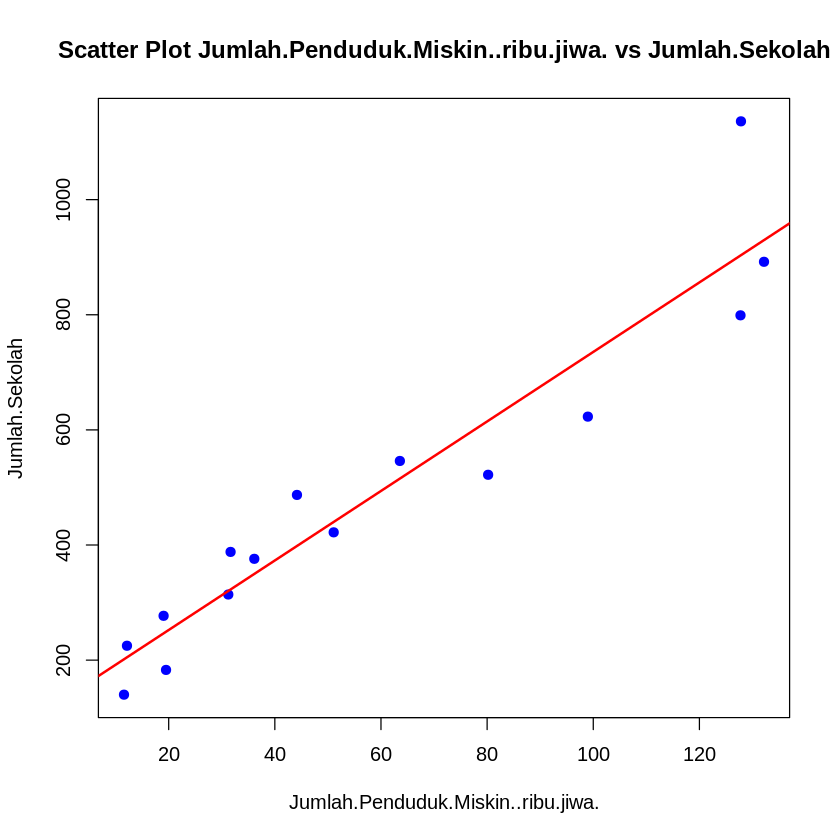

In [15]:
plot(data_sekolah[[var_x]], data_sekolah[[var_y]],
     main = paste("Scatter Plot", var_x, "vs", var_y),
     xlab = var_x, ylab = var_y,
     pch = 19, col = "blue")

abline(lm(data_sekolah[[var_y]] ~ data_sekolah[[var_x]]),
       col = "red", lwd = 2)

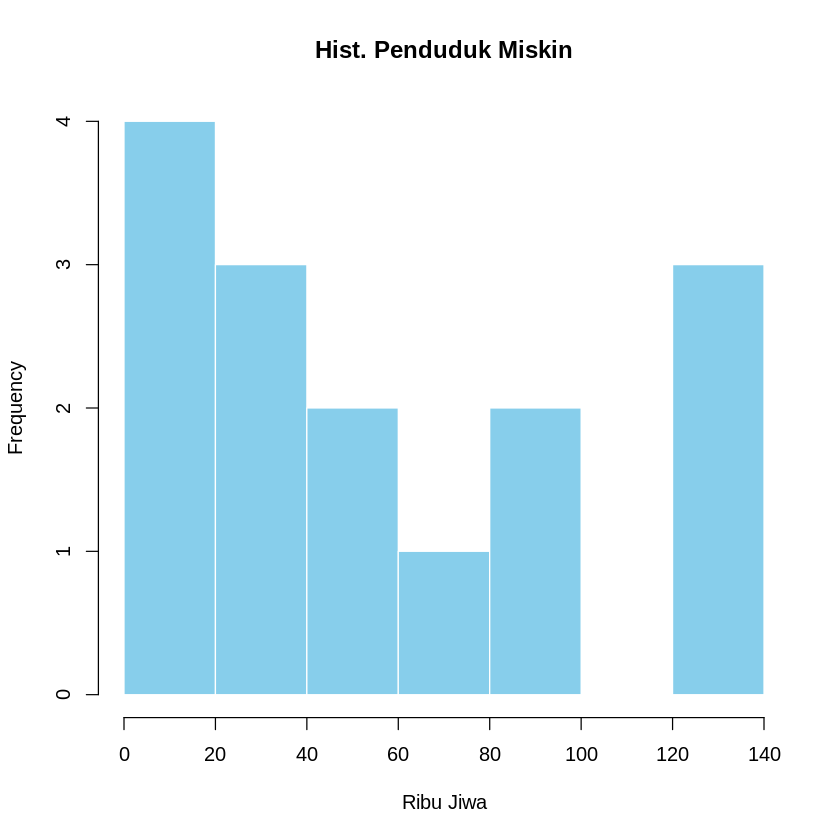

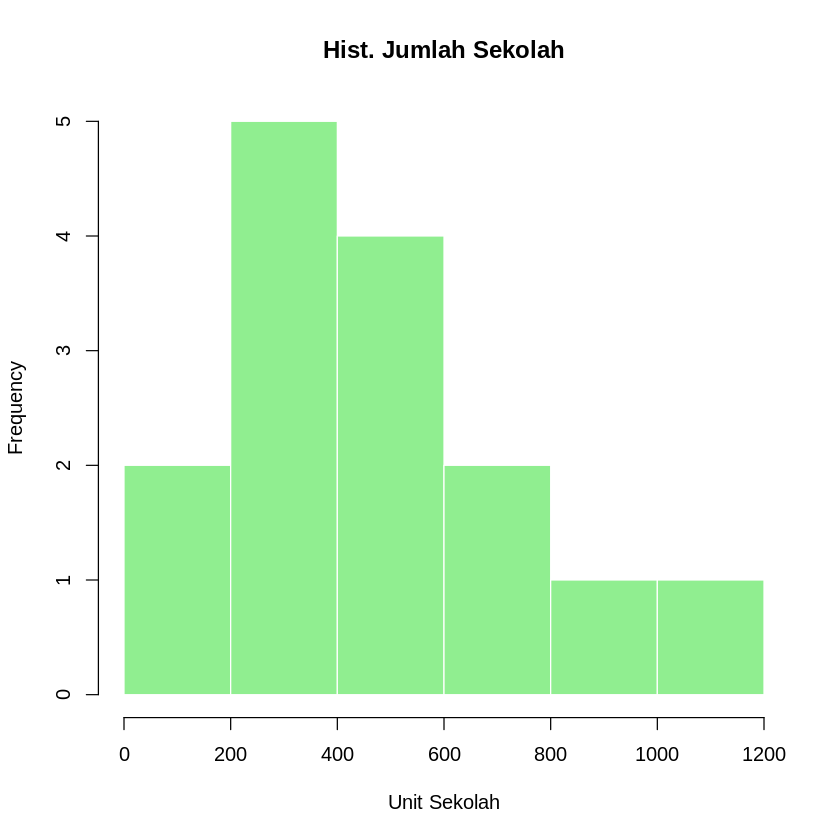

In [16]:
# Histogram Penduduk Miskin
hist(data_sekolah[[var_x]],
     main = "Hist. Penduduk Miskin",
     xlab = "Ribu Jiwa",
     col = "skyblue",
     border = "white")

# Histogram Jumlah Sekolah
hist(data_sekolah[[var_y]],
     main = "Hist. Jumlah Sekolah",
     xlab = "Unit Sekolah",
     col = "lightgreen",
     border = "white")

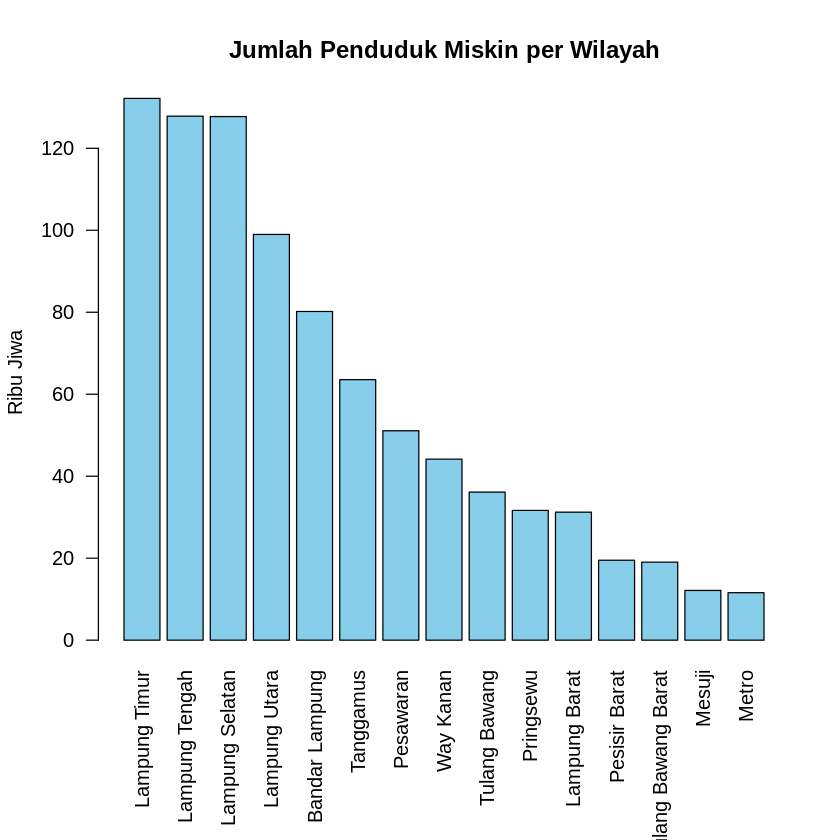

In [17]:
# Barplot
data_sekolah_sorted <- data_sekolah[order(
  data_sekolah$Jumlah.Penduduk.Miskin..ribu.jiwa.,
  decreasing = TRUE
), ]

par(mar = c(8, 4, 4, 2) + 0.1)
barplot(data_sekolah_sorted$Jumlah.Penduduk.Miskin..ribu.jiwa.,
        names.arg = data_sekolah_sorted$Wilayah,
        main = "Jumlah Penduduk Miskin per Wilayah",
        ylab = "Ribu Jiwa",
        col = "skyblue",
        las = 2)
par(mar = c(5, 4, 4, 2) + 0.1)

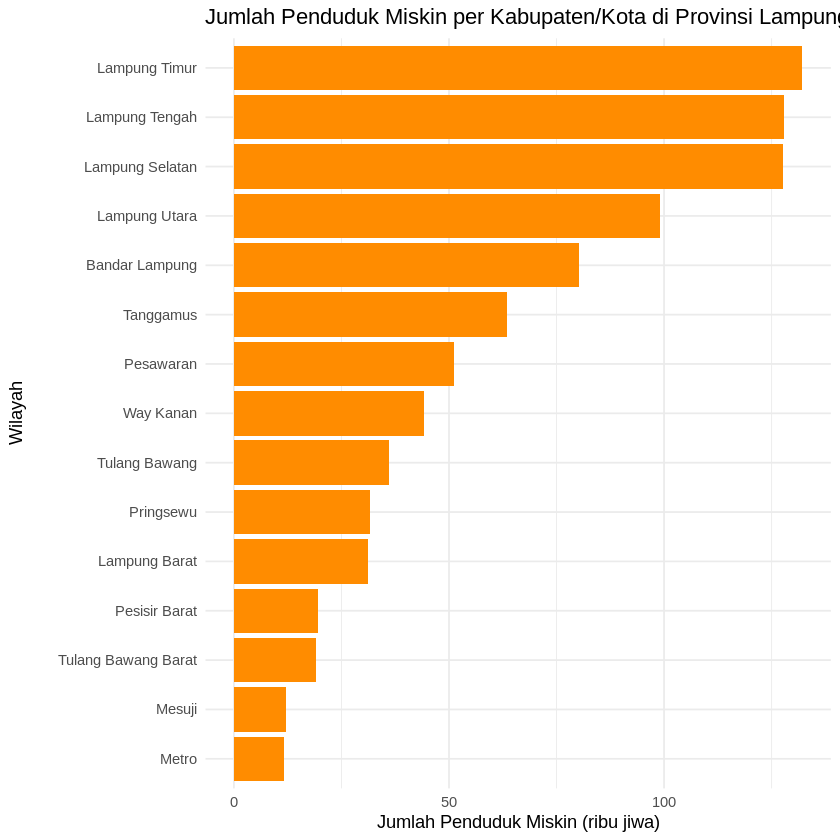

In [24]:
ggplot(data_sekolah, aes(x = Jumlah.Penduduk.Miskin..ribu.jiwa., y = reorder(Wilayah, Jumlah.Penduduk.Miskin..ribu.jiwa.))) +
  geom_col(fill = "darkorange") +
  labs(title = "Jumlah Penduduk Miskin per Kabupaten/Kota di Provinsi Lampung",
       x = "Jumlah Penduduk Miskin (ribu jiwa)",
       y = "Wilayah") +
  theme_minimal()

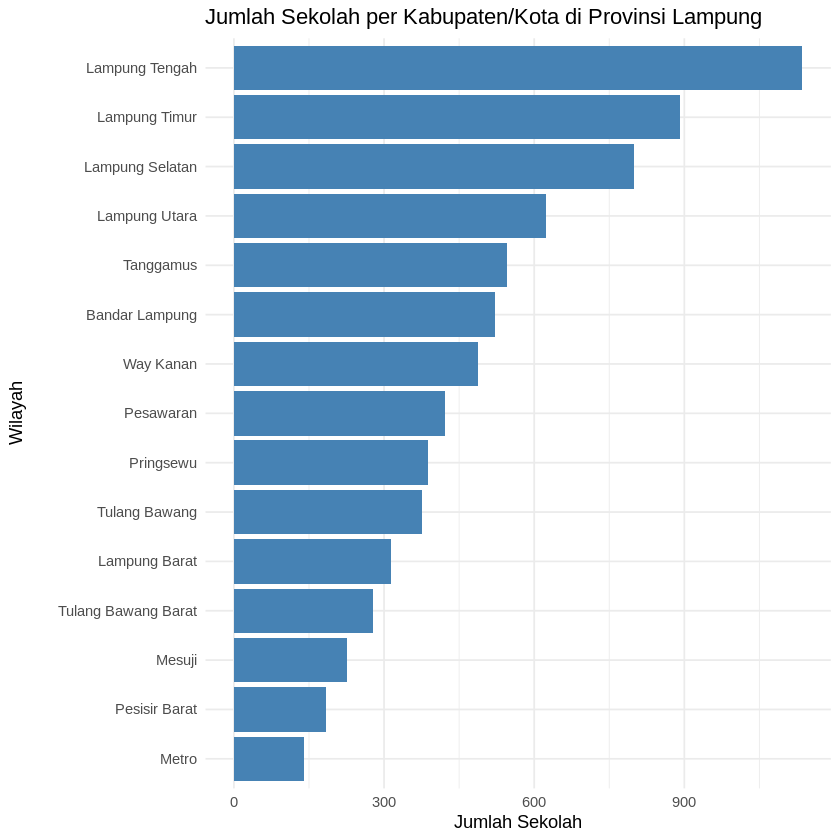

In [19]:
# Bar Plot Jumlah Sekolah per Wilayah
ggplot(data_sekolah, aes(x = reorder(Wilayah, Jumlah.Sekolah), y = Jumlah.Sekolah)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Jumlah Sekolah per Kabupaten/Kota di Provinsi Lampung",
       x = "Wilayah",
       y = "Jumlah Sekolah") +
  theme_minimal()

In [20]:
n <- nrow(data_sekolah)

# Model regresi penuh untuk mendapatkan beta1_full
model_full <- lm(Jumlah.Sekolah ~ Jumlah.Penduduk.Miskin..ribu.jiwa., data = data_sekolah)
beta1_full <- coef(model_full)[2]

beta1_jack <- numeric(n)

for (i in 1:n) {
  # Model regresi tanpa observasi ke-i (Leave-One-Out)
  model_loo <- lm(Jumlah.Sekolah ~ Jumlah.Penduduk.Miskin..ribu.jiwa., data = data_sekolah[-i, ])
  beta1_jack[i] <- coef(model_loo)[2]
}

# Tabel iterasi beta1
cat("\n--- Iterasi Jackknife Beta1 (Koefisien Regresi) ---\n")
print(data.frame(No = 1:n, Hapus = data_sekolah$Wilayah,
                  Beta1 = round(beta1_jack, 6)))

# Pseudovalue beta1
pseudo_b1 <- n * beta1_full - (n - 1) * beta1_jack

# Estimasi Jackknife
beta1_jack_est <- mean(pseudo_b1)

# Variansi & SE
var_b1_jack <- var(pseudo_b1) / n
se_b1_jack <- sqrt(var_b1_jack)

# Bias Jackknife
bias_b1 <- (n - 1) * (mean(beta1_jack) - beta1_full)

# CI 95%
ci_b1_lower <- beta1_jack_est - 1.96 * se_b1_jack
ci_b1_upper <- beta1_jack_est + 1.96 * se_b1_jack

cat("\n--- Hasil Analisis Jackknife Regresi Beta1 ---\n")
cat("Beta1 Full Model: ", beta1_full, "\n")
cat("Estimasi Jackknife Beta1: ", beta1_jack_est, "\n")
cat("Bias Jackknife Beta1: ", bias_b1, "\n")
cat("Standard Error Jackknife Beta1: ", se_b1_jack, "\n")
cat("Interval Kepercayaan 95% untuk Beta1: (", ci_b1_lower, ", ", ci_b1_upper, ")\n")


--- Iterasi Jackknife Beta1 (Koefisien Regresi) ---
   No               Hapus    Beta1
1   1       Lampung Barat 6.031296
2   2           Tanggamus 6.032981
3   3     Lampung Selatan 6.389386
4   4       Lampung Timur 6.178201
5   5      Lampung Tengah 5.251692
6   6       Lampung Utara 6.219090
7   7           Way Kanan 6.091917
8   8       Tulang Bawang 6.063044
9   9           Pesawaran 6.032568
10 10           Pringsewu 6.112249
11 11              Mesuji 6.079806
12 12 Tulang Bawang Barat 6.090516
13 13       Pesisir Barat 5.926283
14 14      Bandar Lampung 6.118762
15 15               Metro 5.909877

--- Hasil Analisis Jackknife Regresi Beta1 ---
Beta1 Full Model:  6.038399 
Estimasi Jackknife Beta1:  6.083497 
Bias Jackknife Beta1:  -0.04509788 
Standard Error Jackknife Beta1:  0.887099 
Interval Kepercayaan 95% untuk Beta1: ( 4.344783 ,  7.822211 )


In [21]:
n <- nrow(data_sekolah)
var_x <- "Jumlah.Penduduk.Miskin..ribu.jiwa."
var_y <- "Jumlah.Sekolah"

# Full sample correlation (r_full)
r_full <- cor(data_sekolah[[var_x]], data_sekolah[[var_y]], method = "pearson")

# Jackknife for Correlation
r_jack_i <- numeric(n)

for (i in 1:n) {
  subsample_x <- data_sekolah[[var_x]][-i]
  subsample_y <- data_sekolah[[var_y]][-i]
  r_jack_i[i] <- cor(subsample_x, subsample_y, method = "pearson")
}

# Pseudovalues
pseudo_r <- n * r_full - (n - 1) * r_jack_i

# Jackknife Estimate
r_jack_est <- mean(pseudo_r)

# Jackknife Standard Error
var_r_jack <- var(pseudo_r) / n
se_r_jack <- sqrt(var_r_jack)

# Jackknife Bias
bias_r_jack <- (n - 1) * (mean(r_jack_i) - r_full)

# Jackknife 95% CI
ci_r_lower <- r_jack_est - 1.96 * se_r_jack
ci_r_upper <- r_jack_est + 1.96 * se_r_jack

cat("\n--- Hasil Analisis Jackknife Korelasi Pearson ---\n")
cat("Korelasi Penuh (r_full): ", r_full, "\n")
cat("Estimasi Jackknife Korelasi: ", r_jack_est, "\n")
cat("Bias Jackknife Korelasi: ", bias_r_jack, "\n")
cat("Standard Error Jackknife Korelasi: ", se_r_jack, "\n")
cat("Interval Kepercayaan 95% untuk Korelasi: (", ci_r_lower, ", ", ci_r_upper, ")\n")

# SE konvensional korelasi (approx normal)
se_r_conv <- (1 - r_full^2) / sqrt(n)

# Fisher Z transformation untuk CI Korelasi Konvensional
z <- 0.5 * log((1 + r_full) / (1 - r_full))
sigma_z <- 1 / sqrt(n - 3)

z_low <- z - 1.96 * sigma_z
z_up <- z + 1.96 * sigma_z

# Back transform Z ke r
ci_r_conv_low <- (exp(2 * z_low) - 1) / (exp(2 * z_low) + 1)
ci_r_conv_up <- (exp(2 * z_up) - 1) / (exp(2 * z_up) + 1)

# Output perbandingan
cat("\n================ PERBANDINGAN METODE ================\n")
comparison <- data.frame(
  Metode = c("Konvensional", "Jackknife"),
  Estimasi_Korelasi = c(r_full, r_jack_est),
  SE = c(se_r_conv, se_r_jack),
  CI_95_Lower = c(ci_r_conv_low, ci_r_lower),
  CI_95_Upper = c(ci_r_conv_up, ci_r_upper)
)

print(comparison)


--- Hasil Analisis Jackknife Korelasi Pearson ---
Korelasi Penuh (r_full):  0.9480756 
Estimasi Jackknife Korelasi:  0.9339071 
Bias Jackknife Korelasi:  0.01416844 
Standard Error Jackknife Korelasi:  0.02449434 
Interval Kepercayaan 95% untuk Korelasi: ( 0.8858982 ,  0.981916 )

================ PERBANDINGAN METODE ================
        Metode Estimasi_Korelasi         SE CI_95_Lower CI_95_Upper
1 Konvensional         0.9480756 0.02611752   0.8473276   0.9829538
2    Jackknife         0.9339071 0.02449434   0.8858982   0.9819160
